# Tarea M21-CD – Lucy Bravo
## Análisis de clasificación con K Vecinos más Cercanos (KNN)
### Predicción de rotación de personal (*employee attrition*)

---

**Base de datos:** `recursos_humanos.csv`

**Objetivo:** Construir un modelo predictivo que permita anticipar qué empleados tienen mayor
probabilidad de abandonar la empresa (`left = 1`), a partir de variables de desempeño,
carga de trabajo, antigüedad y condiciones laborales.

**Variables:**

| Variable | Descripción |
|---|---|
| `satisfaction_level` | Nivel de satisfacción del empleado (0–1) |
| `last_evaluation` | Puntaje obtenido en la última evaluación (0–1) |
| `number_project` | Número de proyectos asignados |
| `average_montly_hours` | Promedio de horas trabajadas al mes |
| `time_spend_company` | Años del empleado en la compañía |
| `Work_accident` | Accidente laboral (1 = Sí, 0 = No) |
| `promotion_last_5years` | Promoción en los últimos 5 años (1 = Sí, 0 = No) |
| `sales` | Departamento donde trabaja (categórica) |
| `salary` | Categoría salarial: low / medium / high (categórica) |
| **`left`** | **Variable objetivo:** el empleado dejó la empresa (1 = Sí, 0 = No) |

**Contenido del análisis:**
1. Carga y exploración inicial de los datos
2. Recodificación de variables categóricas (`pd.get_dummies`)
3. Análisis exploratorio: ¿está equilibrada la base de datos?
4. Modelo KNN evaluando k = 1, 2, …, 20 (con y sin escalado)
5. Tabla comparativa de métricas y selección de la k óptima
6. Mapa de calor de la matriz de confusión e interpretación verbal
7. Curva ROC e interpretación
8. Conclusiones y recomendaciones para el área de Recursos Humanos


---
## 1. Importación de librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y evaluación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

import warnings
warnings.filterwarnings('ignore')

# Configuración estética
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 2. Carga y exploración inicial de la base de datos

In [2]:
# Carga del archivo
df = pd.read_csv('recursos_humanos.csv')

print(f'Registros (filas): {df.shape[0]:,}')
print(f'Variables (columnas): {df.shape[1]}')
df.head(10)

Registros (filas): 14,999
Variables (columnas): 10


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [3]:
# Estructura y tipos de dato
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [4]:
# Estadísticos descriptivos de las variables numéricas
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,0.613,0.249,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,0.716,0.171,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,3.803,1.233,2.00,3.00,4.00,5.00,7.0
average_montly_hours,14999.0,201.050,49.943,96.00,156.00,200.00,245.00,310.0
time_spend_company,14999.0,3.498,1.460,2.00,3.00,3.00,4.00,10.0
Work_accident,14999.0,0.145,0.352,0.00,0.00,0.00,0.00,1.0
left,14999.0,0.238,0.426,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,14999.0,0.021,0.144,0.00,0.00,0.00,0.00,1.0


In [5]:
# Revisión de calidad de datos
print('Valores nulos por variable:')
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')
print(f'Filas duplicadas: {df.duplicated().sum():,}')

Valores nulos por variable:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

Total de valores nulos: 0


Filas duplicadas: 3,008


**Comentario sobre la calidad de los datos:**

La base contiene **14,999 registros y 10 variables**, **sin valores nulos**, por lo que no es
necesario imputar datos faltantes.

Sí se detectan **3,008 filas duplicadas**. En este tipo de base esto es esperable: como todas las
variables son de baja cardinalidad (por ejemplo, satisfacción redondeada a 2 decimales y horas
mensuales en enteros), dos empleados distintos pueden coincidir exactamente en todos sus valores.
Es decir, **no son necesariamente errores de captura sino perfiles laborales repetidos**.
Se conservarán para el modelo principal —tal como viene la base original— pero en la sección 9 se
hace una **prueba de robustez eliminándolos**, para verificar que la conclusión no dependa de ellos.

In [6]:
# Categorías presentes en las variables cualitativas
print('Departamentos (sales):', df['sales'].nunique(), 'categorías')
print(df['sales'].value_counts(), '\n')
print('Nivel salarial (salary):', df['salary'].nunique(), 'categorías')
print(df['salary'].value_counts())

Departamentos (sales): 10 categorías
sales
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64 

Nivel salarial (salary): 3 categorías
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


---
## 3. Análisis Exploratorio de Datos (EDA): ¿está equilibrada la base de datos?

Una base **equilibrada** es aquella en la que las categorías de la variable a predecir aparecen en
proporciones similares (idealmente ~50 % / 50 % en un problema binario). El desequilibrio importa
porque un clasificador puede alcanzar una exactitud alta simplemente prediciendo siempre la clase
mayoritaria, sin aprender realmente nada útil.

In [7]:
# Distribución de la variable objetivo
conteo = df['left'].value_counts().sort_index()
porcentaje = df['left'].value_counts(normalize=True).sort_index() * 100

resumen = pd.DataFrame({
    'Categoría': ['0 = Se queda', '1 = Se va'],
    'Frecuencia': conteo.values,
    'Porcentaje (%)': porcentaje.round(2).values
})
print(resumen.to_string(index=False))
print(f'\nRazón de desequilibrio (mayoritaria : minoritaria) = '
      f'{conteo[0]/conteo[1]:.2f} : 1')

   Categoría  Frecuencia  Porcentaje (%)
0 = Se queda       11428           76.19
   1 = Se va        3571           23.81

Razón de desequilibrio (mayoritaria : minoritaria) = 3.20 : 1


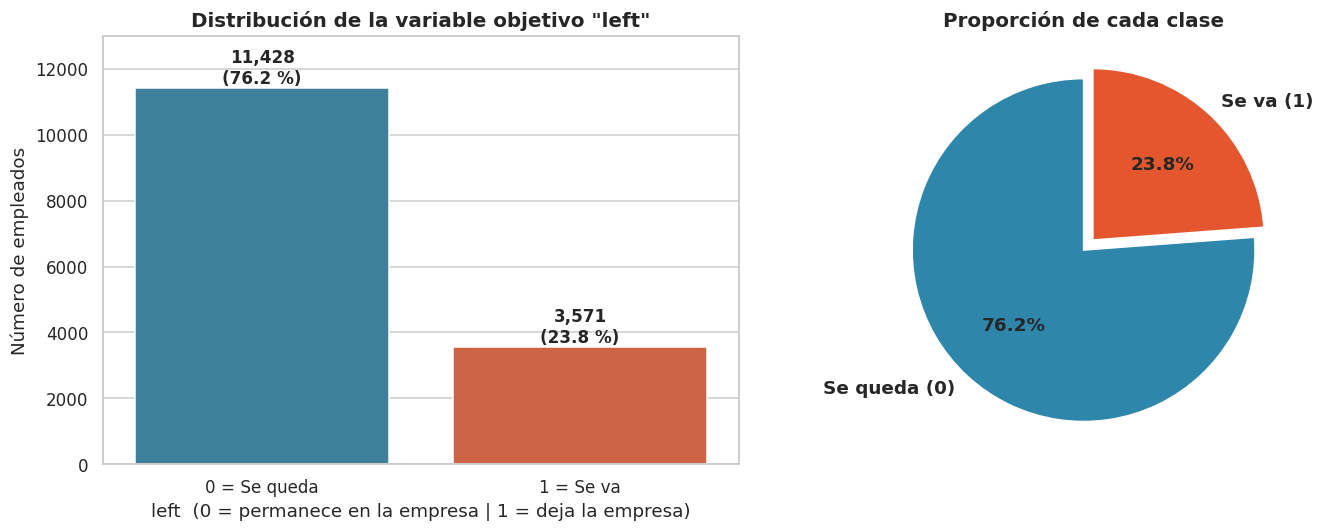

In [8]:
# Visualización del balance de clases
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

colores = ['#2E86AB', '#E4572E']
sns.countplot(x='left', data=df, hue='left', palette=colores, legend=False, ax=ax[0])
ax[0].set_title('Distribución de la variable objetivo "left"', fontsize=13, weight='bold')
ax[0].set_xlabel('left  (0 = permanece en la empresa | 1 = deja la empresa)')
ax[0].set_ylabel('Número de empleados')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['0 = Se queda', '1 = Se va'])
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f} %)',
                   (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom', fontsize=11, weight='bold')
ax[0].set_ylim(0, 13000)

ax[1].pie(conteo, labels=['Se queda (0)', 'Se va (1)'], autopct='%1.1f%%',
          colors=colores, startangle=90, explode=(0, 0.08),
          textprops={'fontsize': 12, 'weight': 'bold'})
ax[1].set_title('Proporción de cada clase', fontsize=13, weight='bold')

plt.tight_layout()
plt.savefig('img_01_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Respuesta: ¿la base está equilibrada?

**No, la base de datos NO está equilibrada.**

- **Clase 0 (permanecen):** 11,428 empleados = **76.19 %**
- **Clase 1 (se van):** 3,571 empleados = **23.81 %**
- La razón de desequilibrio es de aproximadamente **3.2 : 1** a favor de quienes permanecen.

**¿Es un desequilibrio grave?** Es un desequilibrio **moderado**. No estamos ante un caso extremo
(como 99 % / 1 %, típico de fraude), pero sí es suficiente para tener dos consecuencias prácticas:

1. **La exactitud (*accuracy*) por sí sola es una métrica engañosa.** Un modelo trivial que
   prediga "nadie se va" para todos los empleados acertaría el **76.19 %** de las veces. Ese valor
   es nuestra **línea base**: cualquier modelo debe superarla claramente para aportar valor.
2. Por eso este análisis reporta además **precisión, sensibilidad (*recall*), especificidad,
   F1-score y AUC**, que sí capturan el desempeño sobre la clase minoritaria —que es justamente la
   que le interesa a Recursos Humanos: **detectar a quien está por irse**.

Adicionalmente, la partición entrenamiento/prueba se hará con **estratificación** (`stratify=y`)
para que ambas muestras conserven la misma proporción 76/24 y las métricas sean comparables.

### 3.2 Exploración de los factores asociados a la rotación

Antes de modelar, revisamos cómo se comporta la salida de empleados según las distintas variables.

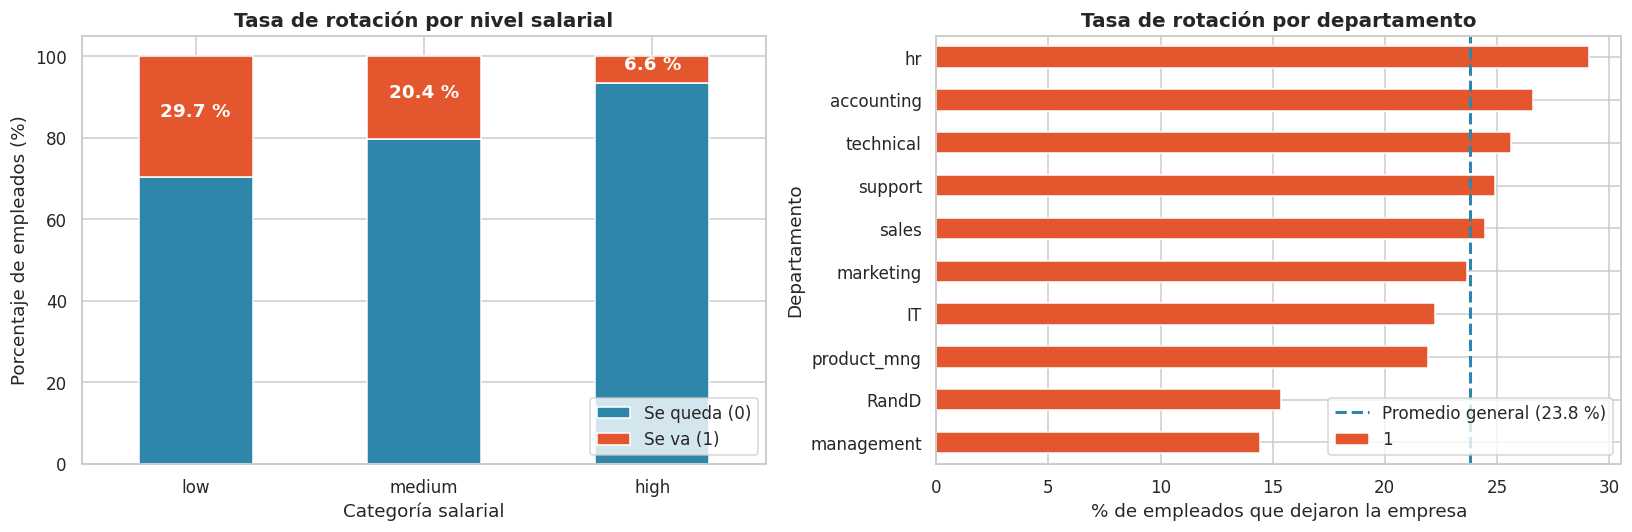

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rotación por nivel salarial
tab_sal = pd.crosstab(df['salary'], df['left'], normalize='index') * 100
tab_sal = tab_sal.reindex(['low', 'medium', 'high'])
tab_sal.plot(kind='bar', stacked=True, color=colores, ax=ax[0], edgecolor='white')
ax[0].set_title('Tasa de rotación por nivel salarial', fontsize=13, weight='bold')
ax[0].set_xlabel('Categoría salarial'); ax[0].set_ylabel('Porcentaje de empleados (%)')
ax[0].legend(['Se queda (0)', 'Se va (1)'], loc='lower right')
ax[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(tab_sal[1]):
    ax[0].text(i, 100 - v/2, f'{v:.1f} %', ha='center', color='white', weight='bold')

# Rotación por departamento
tab_dep = (pd.crosstab(df['sales'], df['left'], normalize='index') * 100)[1].sort_values()
tab_dep.plot(kind='barh', color='#E4572E', ax=ax[1])
ax[1].set_title('Tasa de rotación por departamento', fontsize=13, weight='bold')
ax[1].set_xlabel('% de empleados que dejaron la empresa'); ax[1].set_ylabel('Departamento')
ax[1].axvline(23.81, color='#2E86AB', ls='--', lw=2, label='Promedio general (23.8 %)')
ax[1].legend()

plt.tight_layout()
plt.savefig('img_02_rotacion_salario_depto.png', dpi=150, bbox_inches='tight')
plt.show()

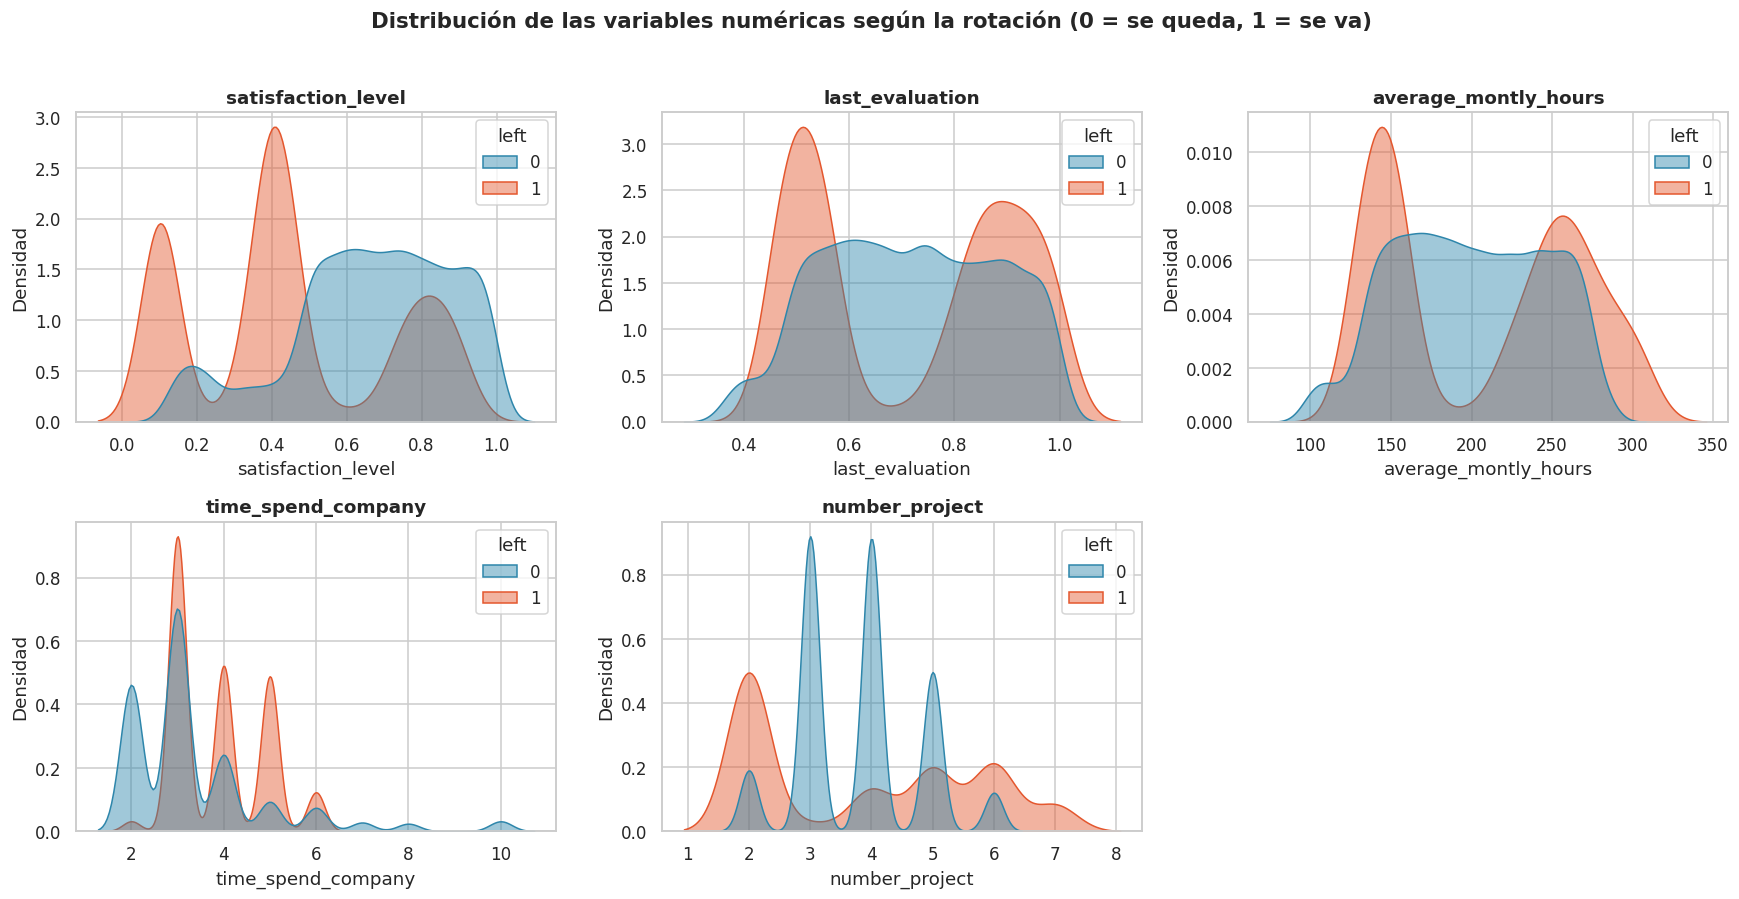

In [10]:
# Distribución de las variables numéricas clave según se hayan ido o no
variables = ['satisfaction_level', 'last_evaluation', 'average_montly_hours',
             'time_spend_company', 'number_project']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for i, var in enumerate(variables):
    sns.kdeplot(data=df, x=var, hue='left', fill=True, alpha=.45,
                palette=colores, ax=axes[i], common_norm=False)
    axes[i].set_title(var, fontsize=12, weight='bold')
    axes[i].set_ylabel('Densidad')
axes[5].axis('off')
plt.suptitle('Distribución de las variables numéricas según la rotación (0 = se queda, 1 = se va)',
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img_03_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

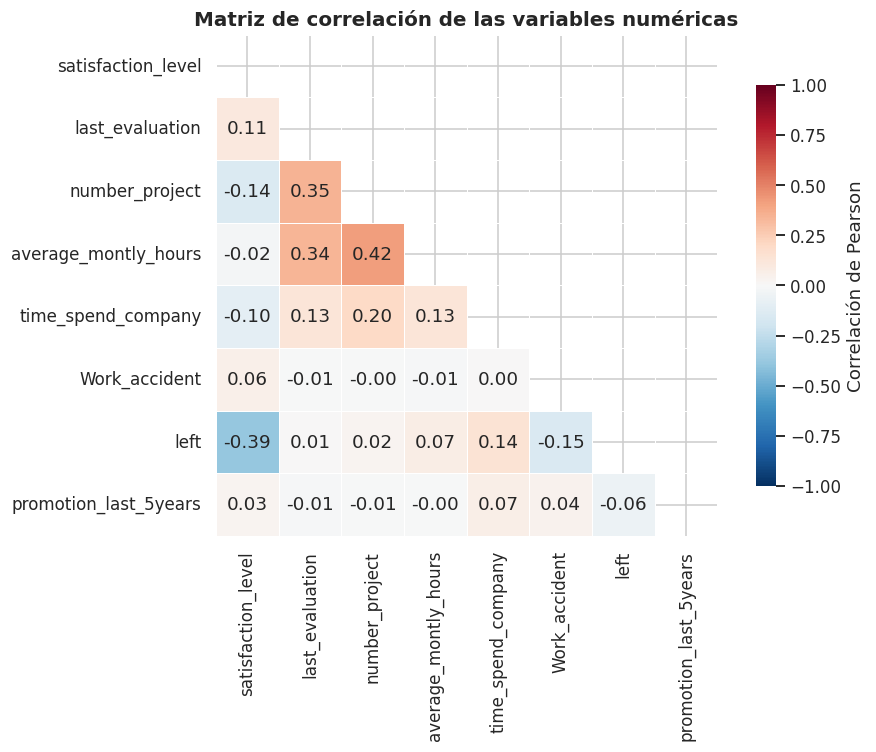


Correlación de cada variable con "left":
time_spend_company       0.145
average_montly_hours     0.071
number_project           0.024
last_evaluation          0.007
promotion_last_5years   -0.062
Work_accident           -0.155
satisfaction_level      -0.388
Name: left, dtype: float64


In [11]:
# Matriz de correlación
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=np.number).corr()
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'shrink': .8, 'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación de las variables numéricas', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('img_04_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelación de cada variable con "left":')
print(corr['left'].drop('left').sort_values(ascending=False).round(3))

**Hallazgos del análisis exploratorio:**

- **El nivel de satisfacción es el factor más asociado a la salida** (correlación de −0.39 con
  `left`): a menor satisfacción, mayor probabilidad de renunciar. La gráfica de densidad muestra
  un grupo muy marcado de empleados que se fueron con satisfacción por debajo de 0.2.
- **El salario importa:** la rotación es de ~29 % entre los de salario bajo frente a solo ~6.6 %
  entre los de salario alto.
- **La antigüedad tiene un patrón no lineal:** las salidas se concentran entre los 3 y 6 años en
  la compañía; quienes superan ese umbral tienden a quedarse.
- **La carga de trabajo es bimodal:** se van tanto los que trabajan muy pocas horas (~130/mes,
  posible desconexión o bajo desempeño) como los que trabajan en exceso (~250–300/mes, agotamiento).
  Lo mismo ocurre con el número de proyectos (2 proyectos o bien 6–7 proyectos).
- **Haber tenido un accidente laboral** se asocia con *menor* rotación (−0.15), y las promociones
  en los últimos 5 años, aunque poco frecuentes, también reducen la salida.

Las correlaciones son moderadas y con patrones **no lineales**, lo cual es una buena señal para
KNN: se trata de un algoritmo que no supone linealidad y puede capturar estos grupos o "vecindarios"
de empleados con perfiles similares.

---
## 4. Recodificación de las variables categóricas

El algoritmo KNN se basa en el cálculo de **distancias** entre observaciones, por lo que requiere
que todas las variables sean numéricas. Las variables `sales` (departamento) y `salary` (nivel
salarial) son categóricas y se transforman con `pd.get_dummies` mediante codificación
*one-hot*.

Se utiliza `drop_first=True` para eliminar una categoría de referencia en cada variable y así
evitar la **multicolinealidad perfecta** (trampa de las variables ficticias). Las categorías de
referencia serán `sales = IT` y `salary = high`.

In [12]:
# Recodificación de variables categóricas mediante variables dummy
df_modelo = pd.get_dummies(df, columns=['sales', 'salary'], drop_first=True)

print(f'Dimensiones antes de la recodificación:  {df.shape}')
print(f'Dimensiones después de la recodificación: {df_modelo.shape}\n')
print('Variables resultantes:')
print(list(df_modelo.columns))
df_modelo.head()

Dimensiones antes de la recodificación:  (14999, 10)
Dimensiones después de la recodificación: (14999, 19)

Variables resultantes:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales_RandD', 'sales_accounting', 'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng', 'sales_sales', 'sales_support', 'sales_technical', 'salary_low', 'salary_medium']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [13]:
# Separación entre variables predictoras (X) y variable objetivo (y)
X = df_modelo.drop('left', axis=1)
y = df_modelo['left']

print(f'X (predictoras): {X.shape[0]:,} observaciones × {X.shape[1]} variables')
print(f'y (objetivo)   : {y.shape[0]:,} observaciones')
print(f'\nDistribución de y -> {dict(y.value_counts().sort_index())}')

X (predictoras): 14,999 observaciones × 18 variables
y (objetivo)   : 14,999 observaciones

Distribución de y -> {0: np.int64(11428), 1: np.int64(3571)}


---
## 5. División en conjuntos de entrenamiento y prueba

Se emplea una partición **70 % entrenamiento / 30 % prueba**, con `stratify=y` para preservar la
proporción original de clases (76 % / 24 %) en ambos subconjuntos, y `random_state=42` para
garantizar la **reproducibilidad** de los resultados.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.0f} %)')
print(f'Conjunto de prueba       : {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.0f} %)\n')
print('Proporción de la clase 1 ("se va"):')
print(f'  - Entrenamiento: {y_train.mean()*100:.2f} %')
print(f'  - Prueba       : {y_test.mean()*100:.2f} %')
print('\nLa estratificación funcionó: ambos conjuntos conservan la proporción original.')

Conjunto de entrenamiento: 10,499 registros (70 %)
Conjunto de prueba       : 4,500 registros (30 %)

Proporción de la clase 1 ("se va"):
  - Entrenamiento: 23.81 %
  - Prueba       : 23.80 %

La estratificación funcionó: ambos conjuntos conservan la proporción original.


### 5.1 Escalado de las variables

KNN clasifica según la **distancia euclidiana** entre observaciones. Si las variables están en
escalas muy distintas, las de mayor magnitud dominan por completo el cálculo. En esta base el
problema es evidente:

- `average_montly_hours` va de ~96 a ~310
- `satisfaction_level` va de 0.09 a 1.0

Una diferencia de 50 horas mensuales pesaría **más de 50 veces** que la diferencia máxima posible
en satisfacción, aun cuando la satisfacción es la variable más predictiva. Por eso se estandarizan
las variables con `StandardScaler` (media 0, desviación estándar 1).

**Nota metodológica importante:** el escalador se ajusta (`fit`) **únicamente con el conjunto de
entrenamiento** y luego se aplica (`transform`) al de prueba. Ajustarlo con todos los datos
filtraría información del conjunto de prueba hacia el entrenamiento (*data leakage*).

Se evaluarán **ambos escenarios (sin escalar y escalado)** para documentar el impacto real del
escalado sobre el desempeño del modelo.

In [15]:
# Ajuste del escalador SOLO con datos de entrenamiento
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc  = escalador.transform(X_test)

print('Comparación de rangos ANTES del escalado (entrenamiento):')
print(X_train[['satisfaction_level', 'last_evaluation', 'average_montly_hours',
               'time_spend_company']].describe().T[['mean', 'std', 'min', 'max']].round(2))

print('\nDESPUÉS del escalado (media ≈ 0, desviación ≈ 1):')
print(pd.DataFrame(X_train_esc, columns=X.columns)[
    ['satisfaction_level', 'last_evaluation', 'average_montly_hours',
     'time_spend_company']].describe().T[['mean', 'std', 'min', 'max']].round(2))

Comparación de rangos ANTES del escalado (entrenamiento):
                        mean    std    min    max
satisfaction_level      0.61   0.25   0.09    1.0
last_evaluation         0.72   0.17   0.36    1.0
average_montly_hours  200.73  49.90  96.00  310.0
time_spend_company      3.51   1.46   2.00   10.0

DESPUÉS del escalado (media ≈ 0, desviación ≈ 1):
                      mean  std   min   max
satisfaction_level    -0.0  1.0 -2.10  1.56
last_evaluation        0.0  1.0 -2.08  1.65
average_montly_hours  -0.0  1.0 -2.10  2.19
time_spend_company    -0.0  1.0 -1.03  4.45


---
## 6. Modelo KNN: búsqueda de la k óptima (k = 1, 2, …, 20)

Se entrena un clasificador KNN para cada valor de k entre 1 y 20, en los dos escenarios (sin
escalar y escalado), y se comparan **todas las métricas de precisión vistas en la lección**:

| Métrica | Fórmula | Qué mide en este problema |
|---|---|---|
| **Exactitud** (*accuracy*) | (VP+VN)/Total | % de empleados clasificados correctamente en total |
| **Precisión** (*precision*) | VP/(VP+FP) | De los que el modelo señala como "se va", ¿qué % realmente se va? |
| **Sensibilidad** (*recall*) | VP/(VP+FN) | De los que realmente se van, ¿qué % logra detectar el modelo? |
| **Especificidad** | VN/(VN+FP) | De los que realmente se quedan, ¿qué % identifica bien? |
| **F1-score** | 2·(P·S)/(P+S) | Media armónica de precisión y sensibilidad (equilibrio entre ambas) |
| **AUC** | Área bajo la curva ROC | Capacidad global de discriminación entre las dos clases |

donde VP = verdaderos positivos, VN = verdaderos negativos, FP = falsos positivos y
FN = falsos negativos.

In [16]:
def evaluar_knn(X_ent, X_pru, etiqueta, k_max=20):
    """Entrena KNN para k = 1..k_max y devuelve una tabla con todas las métricas."""
    resultados = []
    for k in range(1, k_max + 1):
        modelo = KNeighborsClassifier(n_neighbors=k)
        modelo.fit(X_ent, y_train)

        y_pred  = modelo.predict(X_pru)
        y_proba = modelo.predict_proba(X_pru)[:, 1]

        vn, fp, fn, vp = confusion_matrix(y_test, y_pred).ravel()

        resultados.append({
            'k': k,
            'Exactitud':    accuracy_score(y_test, y_pred),
            'Precisión':    precision_score(y_test, y_pred),
            'Sensibilidad': recall_score(y_test, y_pred),
            'Especificidad': vn / (vn + fp),
            'F1-score':     f1_score(y_test, y_pred),
            'AUC':          roc_auc_score(y_test, y_proba)
        })
    tabla = pd.DataFrame(resultados)
    print(f'--- Escenario: {etiqueta} ---')
    return tabla

# Escenario A: sin escalado
tabla_sin = evaluar_knn(X_train, X_test, 'DATOS SIN ESCALAR')
tabla_sin.round(4).style.background_gradient(cmap='Greens', subset=['Exactitud', 'F1-score', 'AUC'])\
    .format({c: '{:.4f}' for c in tabla_sin.columns if c != 'k'})

--- Escenario: DATOS SIN ESCALAR ---


,k,Exactitud,Precisión,Sensibilidad,Especificidad,F1-score,AUC
0,1,0.9553,0.8712,0.9533,0.9560,0.9104,0.9546
1,2,0.9500,0.9036,0.8842,0.9705,0.8938,0.9663
2,3,0.9449,0.8490,0.9346,0.9481,0.8898,0.9695
3,4,0.9464,0.8800,0.8973,0.9618,0.8886,0.9709
4,5,0.9418,0.8460,0.9234,0.9475,0.8830,0.9711
5,6,0.9458,0.8676,0.9113,0.9565,0.8889,0.9709
6,7,0.9420,0.8432,0.9290,0.9460,0.8841,0.9709
7,8,0.9442,0.8590,0.9160,0.9530,0.8866,0.9703
8,9,0.9402,0.8370,0.9300,0.9434,0.8810,0.9700
9,10,0.9422,0.8499,0.9197,0.9493,0.8834,0.9701


In [17]:
# Escenario B: con escalado (StandardScaler)
tabla_con = evaluar_knn(X_train_esc, X_test_esc, 'DATOS ESCALADOS')
tabla_con.round(4).style.background_gradient(cmap='Blues', subset=['Exactitud', 'F1-score', 'AUC'])\
    .format({c: '{:.4f}' for c in tabla_con.columns if c != 'k'})

--- Escenario: DATOS ESCALADOS ---


,k,Exactitud,Precisión,Sensibilidad,Especificidad,F1-score,AUC
0,1,0.9620,0.8934,0.9542,0.9644,0.9228,0.9593
1,2,0.9589,0.9195,0.9066,0.9752,0.9130,0.9659
2,3,0.9464,0.8660,0.9169,0.9557,0.8907,0.9689
3,4,0.9473,0.8949,0.8824,0.9676,0.8886,0.9695
4,5,0.9398,0.8597,0.8926,0.9545,0.8759,0.9699
5,6,0.9456,0.8874,0.8833,0.9650,0.8854,0.9699
6,7,0.9413,0.8685,0.8880,0.9580,0.8781,0.9692
7,8,0.9429,0.8783,0.8824,0.9618,0.8803,0.9705
8,9,0.9398,0.8623,0.8889,0.9557,0.8754,0.9719
9,10,0.9418,0.8742,0.8824,0.9603,0.8783,0.9716


In [18]:
# Tabla comparativa resumida entre ambos escenarios
comparacion = pd.DataFrame({
    'k': tabla_sin['k'],
    'Exactitud SIN escalar': tabla_sin['Exactitud'],
    'Exactitud CON escalado': tabla_con['Exactitud'],
    'F1 SIN escalar': tabla_sin['F1-score'],
    'F1 CON escalado': tabla_con['F1-score'],
    'AUC SIN escalar': tabla_sin['AUC'],
    'AUC CON escalado': tabla_con['AUC'],
})
comparacion['Mejora en F1'] = comparacion['F1 CON escalado'] - comparacion['F1 SIN escalar']
print(comparacion.round(4).to_string(index=False))

print(f"""
Mejor exactitud SIN escalar : {tabla_sin['Exactitud'].max():.4f}  (k = {tabla_sin.loc[tabla_sin['Exactitud'].idxmax(), 'k']})
Mejor exactitud CON escalado: {tabla_con['Exactitud'].max():.4f}  (k = {tabla_con.loc[tabla_con['Exactitud'].idxmax(), 'k']})
Mejor F1-score  CON escalado: {tabla_con['F1-score'].max():.4f}  (k = {tabla_con.loc[tabla_con['F1-score'].idxmax(), 'k']})
""")

 k  Exactitud SIN escalar  Exactitud CON escalado  F1 SIN escalar  F1 CON escalado  AUC SIN escalar  AUC CON escalado  Mejora en F1
 1                 0.9553                  0.9620          0.9104           0.9228           0.9546            0.9593        0.0124
 2                 0.9500                  0.9589          0.8938           0.9130           0.9663            0.9659        0.0192
 3                 0.9449                  0.9464          0.8898           0.8907           0.9695            0.9689        0.0009
 4                 0.9464                  0.9473          0.8886           0.8886           0.9709            0.9695       -0.0000
 5                 0.9418                  0.9398          0.8830           0.8759           0.9711            0.9699       -0.0072
 6                 0.9458                  0.9456          0.8889           0.8854           0.9709            0.9699       -0.0035
 7                 0.9420                  0.9413          0.8841           

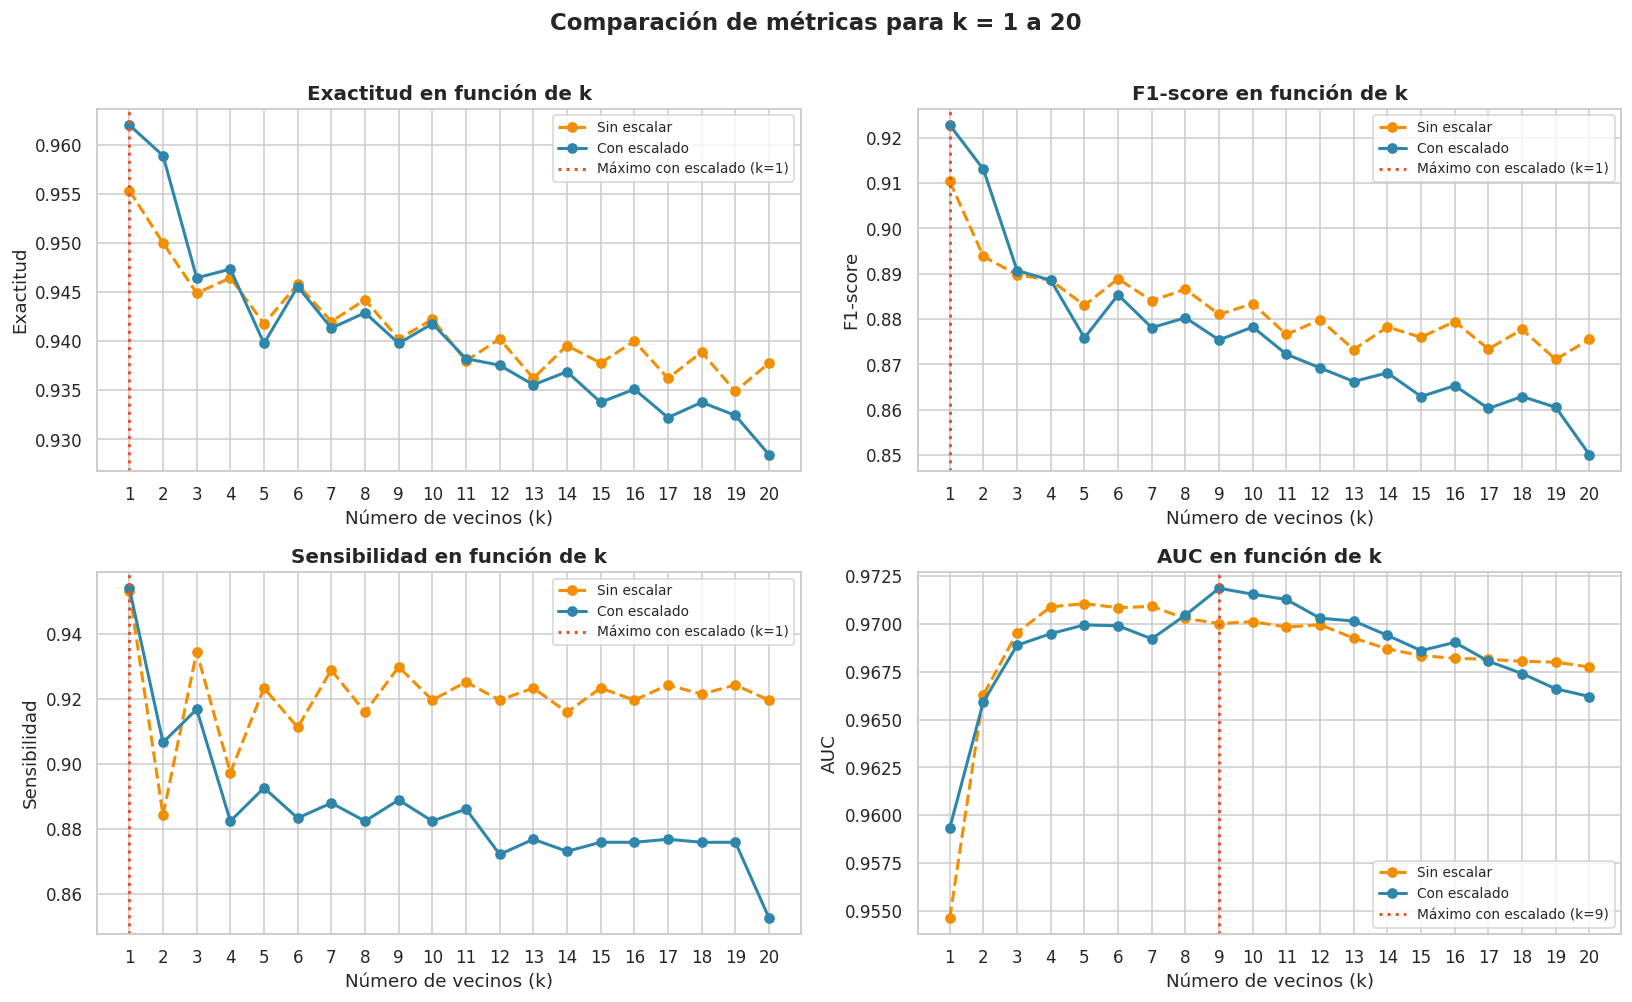

In [19]:
# Visualización comparativa de las métricas en función de k
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

metricas = ['Exactitud', 'F1-score', 'Sensibilidad', 'AUC']
for ax, m in zip(axes.ravel(), metricas):
    ax.plot(tabla_sin['k'], tabla_sin[m], 'o--', color='#F18F01',
            label='Sin escalar', lw=2, markersize=6)
    ax.plot(tabla_con['k'], tabla_con[m], 'o-', color='#2E86AB',
            label='Con escalado', lw=2, markersize=6)
    k_mejor = tabla_con.loc[tabla_con[m].idxmax(), 'k']
    ax.axvline(k_mejor, color='#E4572E', ls=':', lw=2,
               label=f'Máximo con escalado (k={int(k_mejor)})')
    ax.set_title(f'{m} en función de k', fontsize=13, weight='bold')
    ax.set_xlabel('Número de vecinos (k)'); ax.set_ylabel(m)
    ax.set_xticks(range(1, 21)); ax.legend(fontsize=9)

plt.suptitle('Comparación de métricas para k = 1 a 20', fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('img_05_metricas_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Lectura de las tablas y del gráfico

**a) El escalado sí mejora el modelo.** Con k = 1 la exactitud pasa de 0.9553 (sin escalar) a
**0.9620** (escalado) y el F1-score de 0.9104 a **0.9228**. La mejora se sostiene en casi todos los
valores de k pequeños, que son justamente los relevantes. Esto confirma lo previsto: al estandarizar,
`satisfaction_level` deja de ser aplastada por `average_montly_hours` en el cálculo de distancias.
**A partir de aquí se trabaja con los datos escalados.**

**b) El desempeño decrece de forma monótona conforme aumenta k.** Exactitud, F1 y sensibilidad
son máximas en k = 1 y descienden de manera sostenida hasta k = 20 (F1 baja de 0.9228 a 0.8501).
Esto tiene una explicación clara: como la clase "se va" es minoritaria (23.8 %), al ampliar el
vecindario aumenta la probabilidad de que la mayoría de los k vecinos pertenezca a la clase
mayoritaria, "diluyendo" a los empleados en riesgo de renunciar. **En bases desequilibradas, una k
grande sesga las predicciones hacia la clase mayoritaria.**

**c) El AUC se comporta distinto.** Alcanza su máximo en valores intermedios (k = 9, AUC = 0.9719)
porque con k = 1 la probabilidad predicha solo puede tomar los valores 0 o 1: no hay gradación y la
curva ROC queda definida por un único punto de corte efectivo. Es una limitación conocida de k = 1,
no un mejor desempeño de clasificación.

Dado que k = 1 es siempre el caso más propenso al **sobreajuste**, antes de recomendarlo se valida
con validación cruzada.

---
## 7. Validación de la k óptima mediante validación cruzada

Elegir k mirando solo el conjunto de prueba tiene un riesgo: podríamos estar ajustando la elección
a las particularidades de esa partición concreta. Para confirmar el resultado se aplica
**validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento**, que no
utiliza en absoluto los datos de prueba.

Se reporta además la **exactitud sobre el propio conjunto de entrenamiento**, que sirve como
diagnóstico de sobreajuste.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
filas_cv = []

for k in range(1, 21):
    # El pipeline garantiza que el escalado se ajuste dentro de cada partición de la validación
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    f1_cv  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1').mean()
    acc_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy').mean()
    pipe.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, pipe.predict(X_train))
    filas_cv.append({'k': k, 'F1 (validación cruzada)': f1_cv,
                     'Exactitud (validación cruzada)': acc_cv,
                     'Exactitud (entrenamiento)': acc_train,
                     'Brecha entrenamiento - VC': acc_train - acc_cv})

tabla_cv = pd.DataFrame(filas_cv)
print(tabla_cv.round(4).to_string(index=False))
print(f"\nMejor k según F1 de validación cruzada: k = {int(tabla_cv.loc[tabla_cv['F1 (validación cruzada)'].idxmax(), 'k'])}")

 k  F1 (validación cruzada)  Exactitud (validación cruzada)  Exactitud (entrenamiento)  Brecha entrenamiento - VC
 1                   0.9193                          0.9604                     1.0000                     0.0396
 2                   0.9089                          0.9573                     0.9895                     0.0322
 3                   0.8905                          0.9465                     0.9744                     0.0279
 4                   0.8948                          0.9506                     0.9686                     0.0180
 5                   0.8796                          0.9418                     0.9605                     0.0187
 6                   0.8869                          0.9467                     0.9572                     0.0106
 7                   0.8778                          0.9412                     0.9519                     0.0107
 8                   0.8734                          0.9400                     0.9525  

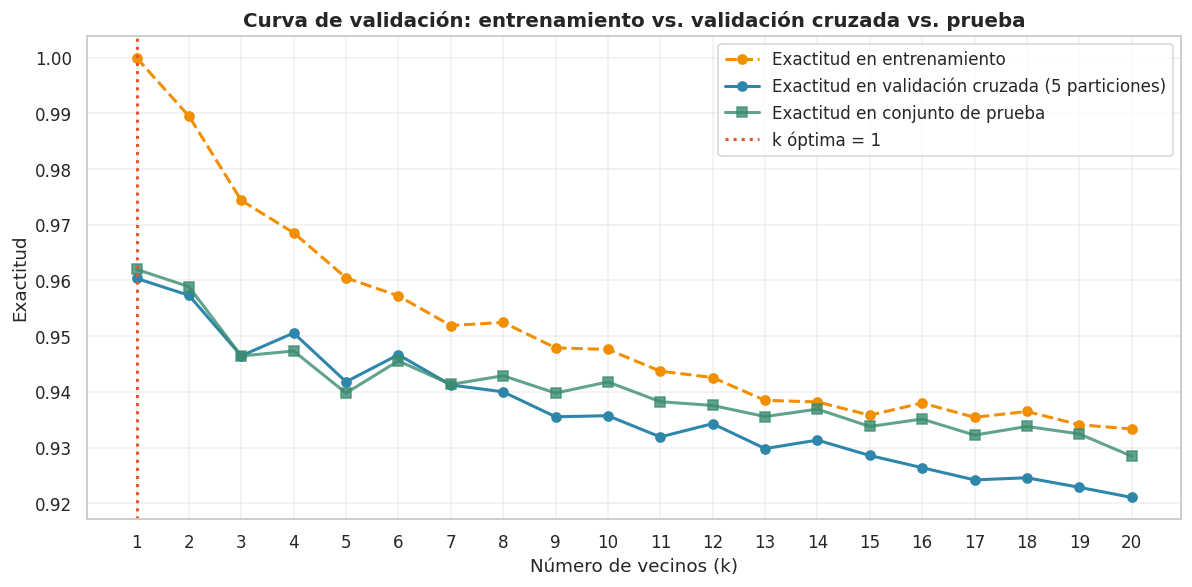

In [21]:
plt.figure(figsize=(11, 5.5))
plt.plot(tabla_cv['k'], tabla_cv['Exactitud (entrenamiento)'], 'o--',
         color='#F18F01', lw=2, label='Exactitud en entrenamiento')
plt.plot(tabla_cv['k'], tabla_cv['Exactitud (validación cruzada)'], 'o-',
         color='#2E86AB', lw=2, label='Exactitud en validación cruzada (5 particiones)')
plt.plot(tabla_con['k'], tabla_con['Exactitud'], 's-',
         color='#3B8C6E', lw=2, alpha=.8, label='Exactitud en conjunto de prueba')
plt.axvline(1, color='#E4572E', ls=':', lw=2, label='k óptima = 1')
plt.title('Curva de validación: entrenamiento vs. validación cruzada vs. prueba',
          fontsize=13, weight='bold')
plt.xlabel('Número de vecinos (k)'); plt.ylabel('Exactitud')
plt.xticks(range(1, 21)); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('img_06_validacion_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Recomendación de la k óptima

> ## **k óptima = 1** (con datos escalados)

**Justificación, respaldada en las tablas anteriores:**

| Criterio | Resultado |
|---|---|
| Mejor exactitud en el conjunto de prueba | **k = 1** (0.9620) |
| Mejor F1-score en el conjunto de prueba | **k = 1** (0.9228) |
| Mejor sensibilidad en el conjunto de prueba | **k = 1** (0.9542) |
| Mejor F1 en validación cruzada (sin usar datos de prueba) | **k = 1** (0.9193) |
| Mejor exactitud en validación cruzada | **k = 1** (0.9604) |

Los tres criterios independientes —conjunto de prueba, validación cruzada y F1 sobre la clase
minoritaria— **coinciden en k = 1**. La coherencia entre la curva de validación cruzada y la del
conjunto de prueba (prácticamente paralelas en el gráfico anterior) indica que no se trata de un
resultado accidental de la partición elegida.

**Discusión honesta sobre k = 1.** Con k = 1 la exactitud en entrenamiento es de 1.0000, lo que
suele ser señal de sobreajuste: cada punto es su propio vecino más cercano. Sin embargo, aquí la
exactitud en validación cruzada (0.9604) y en prueba (0.9620) también son las más altas, es decir,
**el modelo generaliza bien pese a memorizar**. Esto ocurre porque las clases forman en este caso
grupos muy compactos y bien separados en el espacio de variables (se aprecia en las densidades de
`satisfaction_level`), de modo que el vecino más cercano casi siempre pertenece a la clase correcta.

**Alternativa conservadora:** si el área de RH prefiriera un modelo menos sensible al ruido y con
mejor calibración de probabilidades, **k = 2** es la segunda mejor opción (exactitud 0.9589,
F1 0.9130, AUC 0.9659) y sacrifica muy poco desempeño a cambio de mayor estabilidad. Si el objetivo
prioritario fuera el ordenamiento por riesgo (*ranking* de empleados según probabilidad de salida),
**k = 9** maximiza el AUC (0.9719).

Para el resto del análisis se utiliza **k = 1**, conforme al criterio solicitado en la actividad.

---
## 8. Matriz de confusión del modelo óptimo

In [22]:
# Entrenamiento del modelo final con la k óptima
k_optima = 1
modelo_final = KNeighborsClassifier(n_neighbors=k_optima)
modelo_final.fit(X_train_esc, y_train)

y_pred  = modelo_final.predict(X_test_esc)
y_proba = modelo_final.predict_proba(X_test_esc)[:, 1]

mc = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = mc.ravel()

print(f'Modelo final: KNN con k = {k_optima} sobre datos escalados')
print(f'Registros evaluados en el conjunto de prueba: {mc.sum():,}\n')
print('Matriz de confusión:')
print(mc)

Modelo final: KNN con k = 1 sobre datos escalados
Registros evaluados en el conjunto de prueba: 4,500

Matriz de confusión:
[[3307  122]
 [  49 1022]]


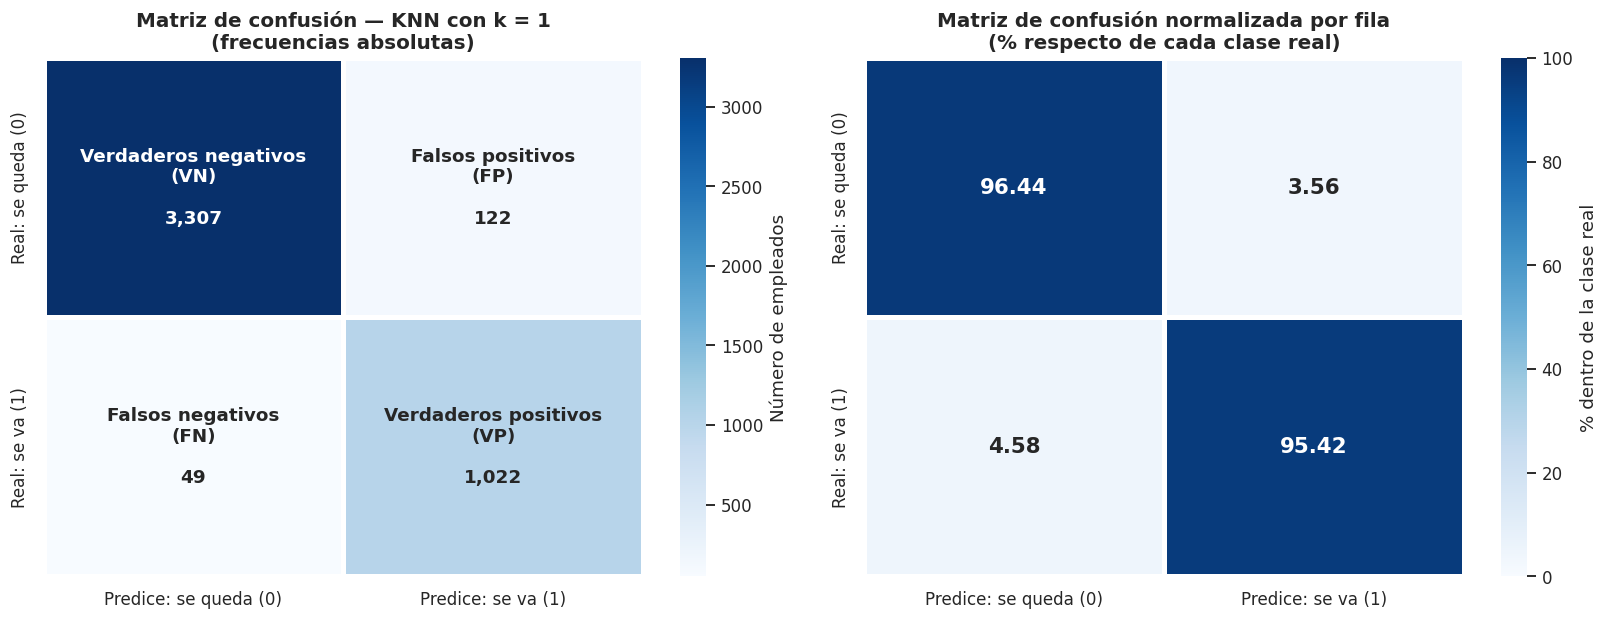

In [23]:
# Mapa de calor de la matriz de confusión
fig, ax = plt.subplots(1, 2, figsize=(15, 5.8))

etiquetas = [f'Verdaderos negativos\n(VN)\n\n{vn:,}', f'Falsos positivos\n(FP)\n\n{fp:,}',
             f'Falsos negativos\n(FN)\n\n{fn:,}', f'Verdaderos positivos\n(VP)\n\n{vp:,}']
etiquetas = np.array(etiquetas).reshape(2, 2)

sns.heatmap(mc, annot=etiquetas, fmt='', cmap='Blues', cbar=True, ax=ax[0],
            linewidths=2, linecolor='white', annot_kws={'size': 12, 'weight': 'bold'},
            xticklabels=['Predice: se queda (0)', 'Predice: se va (1)'],
            yticklabels=['Real: se queda (0)', 'Real: se va (1)'],
            cbar_kws={'label': 'Número de empleados'})
ax[0].set_title(f'Matriz de confusión — KNN con k = {k_optima}\n(frecuencias absolutas)',
                fontsize=13, weight='bold')

# Versión normalizada por fila (porcentaje sobre la clase real)
mc_norm = mc.astype(float) / mc.sum(axis=1, keepdims=True) * 100
sns.heatmap(mc_norm, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax[1],
            linewidths=2, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Predice: se queda (0)', 'Predice: se va (1)'],
            yticklabels=['Real: se queda (0)', 'Real: se va (1)'],
            vmin=0, vmax=100, cbar_kws={'label': '% dentro de la clase real'})
ax[1].set_title('Matriz de confusión normalizada por fila\n(% respecto de cada clase real)',
                fontsize=13, weight='bold')

plt.tight_layout()
plt.savefig('img_07_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Métricas derivadas de la matriz de confusión
exactitud     = (vp + vn) / mc.sum()
precision_1   = vp / (vp + fp)
sensibilidad  = vp / (vp + fn)
especificidad = vn / (vn + fp)
f1            = 2 * precision_1 * sensibilidad / (precision_1 + sensibilidad)
tasa_error    = (fp + fn) / mc.sum()

print(f'''RESUMEN DE MÉTRICAS — KNN con k = {k_optima}
{'='*52}
Verdaderos negativos (VN): {vn:>5,}   Falsos positivos (FP): {fp:>5,}
Falsos negativos     (FN): {fn:>5,}   Verdaderos positivos (VP): {vp:>5,}
{'-'*52}
Exactitud (accuracy)      : {exactitud:.4f}  ({exactitud*100:.2f} %)
Precisión (clase "se va") : {precision_1:.4f}  ({precision_1*100:.2f} %)
Sensibilidad (recall)     : {sensibilidad:.4f}  ({sensibilidad*100:.2f} %)
Especificidad             : {especificidad:.4f}  ({especificidad*100:.2f} %)
F1-score                  : {f1:.4f}
Tasa de error             : {tasa_error:.4f}  ({tasa_error*100:.2f} %)
{'='*52}''')

print('\nReporte de clasificación completo:\n')
print(classification_report(y_test, y_pred,
                           target_names=['Se queda (0)', 'Se va (1)'], digits=4))

RESUMEN DE MÉTRICAS — KNN con k = 1
Verdaderos negativos (VN): 3,307   Falsos positivos (FP):   122
Falsos negativos     (FN):    49   Verdaderos positivos (VP): 1,022
----------------------------------------------------
Exactitud (accuracy)      : 0.9620  (96.20 %)
Precisión (clase "se va") : 0.8934  (89.34 %)
Sensibilidad (recall)     : 0.9542  (95.42 %)
Especificidad             : 0.9644  (96.44 %)
F1-score                  : 0.9228
Tasa de error             : 0.0380  (3.80 %)

Reporte de clasificación completo:

              precision    recall  f1-score   support

Se queda (0)     0.9854    0.9644    0.9748      3429
   Se va (1)     0.8934    0.9542    0.9228      1071

    accuracy                         0.9620      4500
   macro avg     0.9394    0.9593    0.9488      4500
weighted avg     0.9635    0.9620    0.9624      4500



### 8.1 Interpretación verbal de cada resultado de la matriz de confusión

El conjunto de prueba contiene **4,500 empleados**: 3,429 que realmente permanecieron y 1,071 que
realmente dejaron la empresa. Cada casilla de la matriz significa lo siguiente:

#### 🟦 Verdaderos Negativos (VN) = 3,307 empleados
Empleados que **efectivamente se quedaron en la empresa y el modelo predijo correctamente que se
quedarían**. Representan el **96.44 %** de todos los empleados que realmente permanecieron. Son
aciertos sobre la clase mayoritaria: el modelo identifica muy bien al personal estable, lo que
evita que RH invierta recursos de retención en gente que no pensaba irse.

#### 🟩 Verdaderos Positivos (VP) = 1,022 empleados
Empleados que **efectivamente renunciaron y el modelo los detectó correctamente**. Equivalen al
**95.42 %** de todas las salidas reales. Este es el resultado más valioso del modelo: de cada 100
empleados que estaban por irse, el modelo alertó sobre 95 con anticipación, lo que le daría a
Recursos Humanos la oportunidad de intervenir.

#### 🟥 Falsos Positivos (FP) = 122 empleados — *Error tipo I*
Empleados que **el modelo señaló como "en riesgo de irse", pero que en realidad se quedaron**.
Es una **falsa alarma**: solo el **3.56 %** del personal que permanecía fue marcado por error.
El costo de este error es relativamente bajo y controlable: implica dedicar una entrevista de
seguimiento, una revisión salarial o una conversación de desarrollo a alguien que no pensaba
renunciar. En el peor de los casos se gasta tiempo del área; en el mejor, refuerza el compromiso
de un colaborador satisfecho.

#### 🟧 Falsos Negativos (FN) = 49 empleados — *Error tipo II*
Empleados que **realmente renunciaron pero el modelo predijo que se quedarían**. Son las **fugas
no detectadas** y representan apenas el **4.58 %** de las salidas reales. **Este es el error más
costoso para la organización**, porque significa perder talento sin ninguna alerta previa: no hubo
oportunidad de negociar, retener ni planear el reemplazo. El costo de reemplazar a un empleado
suele estimarse entre el 50 % y el 200 % de su salario anual, además de la pérdida de conocimiento
y de la carga adicional para el equipo. Que solo 49 de 1,071 salidas pasaran desapercibidas es un
resultado muy sólido.

#### Lectura global
- **Exactitud = 96.20 %**: el modelo clasifica correctamente a 4,329 de los 4,500 empleados
  evaluados. Comparado con la línea base de 76.19 % (predecir que nadie se va), **el modelo aporta
  una mejora real de 20 puntos porcentuales**, así que su buen desempeño no es un artefacto del
  desequilibrio de clases.
- **Precisión = 89.34 %**: cuando el modelo enciende una alerta, acierta casi 9 de cada 10 veces.
  Las intervenciones de retención estarían bien dirigidas.
- **Sensibilidad = 95.42 %**: el modelo captura la gran mayoría de las salidas reales, que es
  exactamente el objetivo del problema.
- El modelo comete **más falsos positivos (122) que falsos negativos (49)**, lo cual es
  **deseable en este contexto de negocio**: es preferible investigar de más a perder talento sin
  aviso. El balance de errores está inclinado hacia el lado correcto.
- **Total de errores: 171 de 4,500 (3.80 %)**.

---
## 9. Curva ROC del modelo óptimo

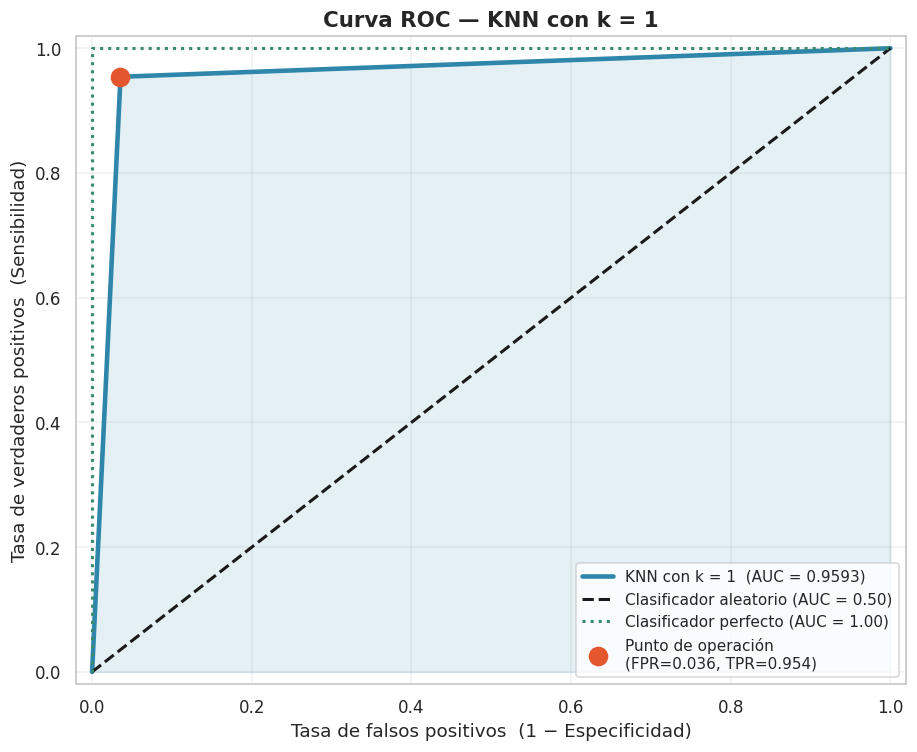

Área bajo la curva (AUC) = 0.9593


In [25]:
# Cálculo de la curva ROC
fpr, tpr, umbrales = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8.5, 7))
plt.plot(fpr, tpr, color='#2E86AB', lw=3,
         label=f'KNN con k = {k_optima}  (AUC = {auc:.4f})')
plt.fill_between(fpr, tpr, alpha=.12, color='#2E86AB')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador aleatorio (AUC = 0.50)')
plt.plot([0, 0, 1], [0, 1, 1], color='#3B8C6E', ls=':', lw=2,
         label='Clasificador perfecto (AUC = 1.00)')
plt.scatter(fp/(fp+vn), vp/(vp+fn), color='#E4572E', s=140, zorder=5,
            label=f'Punto de operación\n(FPR={fp/(fp+vn):.3f}, TPR={vp/(vp+fn):.3f})')

plt.xlim(-0.02, 1.02); plt.ylim(-0.02, 1.02)
plt.xlabel('Tasa de falsos positivos  (1 − Especificidad)', fontsize=12)
plt.ylabel('Tasa de verdaderos positivos  (Sensibilidad)', fontsize=12)
plt.title(f'Curva ROC — KNN con k = {k_optima}', fontsize=14, weight='bold')
plt.legend(loc='lower right', fontsize=10); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('img_08_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Área bajo la curva (AUC) = {auc:.4f}')

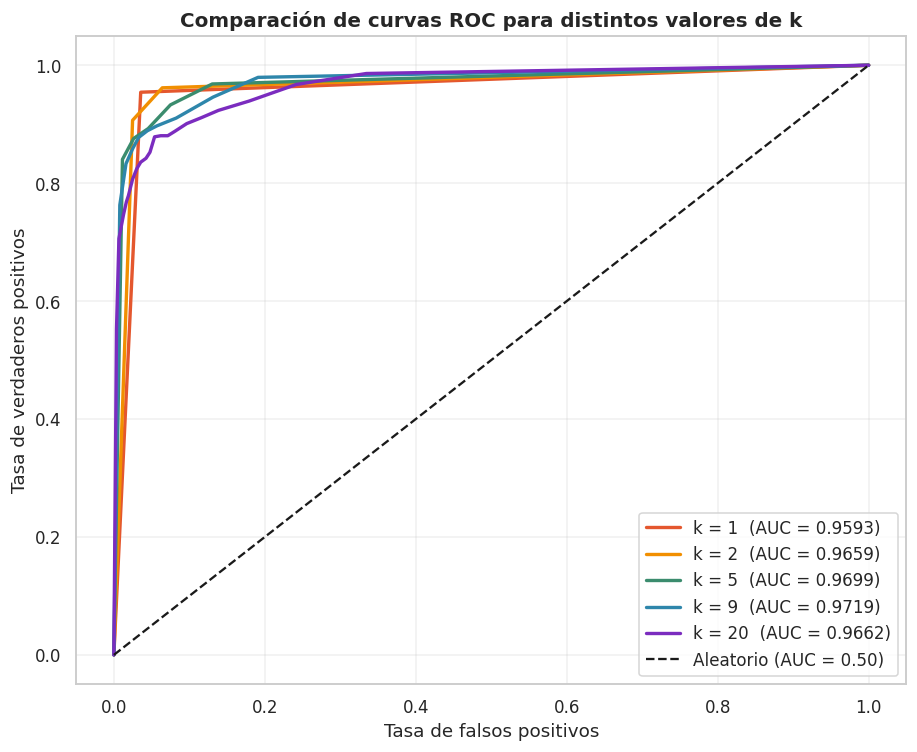

In [26]:
# Curvas ROC comparativas para distintos valores de k
plt.figure(figsize=(8.5, 7))
for k, color in zip([1, 2, 5, 9, 20], ['#E4572E', '#F18F01', '#3B8C6E', '#2E86AB', '#7B2CBF']):
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_esc, y_train)
    pr = m.predict_proba(X_test_esc)[:, 1]
    f, t, _ = roc_curve(y_test, pr)
    plt.plot(f, t, lw=2.2, color=color, label=f'k = {k}  (AUC = {roc_auc_score(y_test, pr):.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatorio (AUC = 0.50)')
plt.xlabel('Tasa de falsos positivos', fontsize=12)
plt.ylabel('Tasa de verdaderos positivos', fontsize=12)
plt.title('Comparación de curvas ROC para distintos valores de k', fontsize=13, weight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('img_09_roc_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.1 Interpretación de la curva ROC

**¿Qué representa la curva?** La curva ROC (*Receiver Operating Characteristic*) muestra el
compromiso entre la **tasa de verdaderos positivos** (sensibilidad: qué porcentaje de las salidas
reales se detecta) en el eje vertical y la **tasa de falsos positivos** (1 − especificidad: qué
porcentaje de quienes se quedan se marca por error) en el eje horizontal, a medida que se mueve el
umbral de decisión. La diagonal punteada representa un clasificador que decide al azar; cuanto más
se acerque la curva a la esquina superior izquierda, mejor es el modelo.

**AUC = 0.9593.** El área bajo la curva se interpreta directamente como una probabilidad: si se
toma **al azar un empleado que renunció y otro que permaneció, hay un 95.93 % de probabilidad de
que el modelo asigne mayor riesgo de salida al que efectivamente renunció**. Bajo los criterios
convencionales de interpretación del AUC:

| Rango de AUC | Calidad de discriminación |
|---|---|
| 0.50 – 0.60 | Nula (equivale al azar) |
| 0.60 – 0.70 | Pobre |
| 0.70 – 0.80 | Aceptable |
| 0.80 – 0.90 | Buena |
| **0.90 – 1.00** | **Excelente** ← nuestro modelo (0.9593) |

**Forma particular de la curva con k = 1.** La curva presenta una forma angulosa, casi de tres
segmentos rectos, en lugar de una curva suave. Esto **no es un error**: con k = 1 el único vecino
consultado determina la predicción, de modo que la probabilidad estimada solo puede valer 0 o 1.
Al existir un único umbral efectivo, la curva se traza esencialmente a partir de **un solo punto de
operación** (marcado en naranja: FPR = 0.036, TPR = 0.954) unido a las esquinas. Ésta es la razón
por la que k = 1 no maximiza el AUC pese a tener la mejor exactitud y el mejor F1.

**Comparación entre valores de k.** En la segunda gráfica se aprecia que valores intermedios de k
(9 y 20) generan curvas **suaves** y con mayor área, porque la proporción de vecinos de cada clase
produce probabilidades graduadas (0, 1/9, 2/9, …). Esta es una distinción práctica relevante:

- Si el objetivo es **clasificar** (decidir sí/no para cada empleado), **k = 1 es la mejor opción**
  y así lo confirman la exactitud, el F1 y la matriz de confusión.
- Si el objetivo es **ordenar por riesgo** (por ejemplo, generar un *ranking* con los 100 empleados
  más propensos a renunciar para priorizar entrevistas de retención), conviene **k = 9**, que
  maximiza el AUC (0.9719) y entrega probabilidades con mayor granularidad.

**El punto de operación** (FPR = 0.036, TPR = 0.954) se ubica muy cerca de la esquina superior
izquierda, lo que confirma visualmente lo que ya mostraba la matriz de confusión: el modelo detecta
el 95.4 % de las renuncias reales generando falsas alarmas en apenas el 3.6 % del personal estable.

---
## 10. Prueba de robustez: comportamiento del modelo sin filas duplicadas

Dado que la base contiene 3,008 registros duplicados, se verifica que la conclusión sobre el
desempeño del modelo no dependa de ellos. Este control es importante porque, en presencia de
duplicados, un registro idéntico puede quedar en entrenamiento y en prueba a la vez, favoreciendo
artificialmente a k = 1.

In [27]:
df_sd = df.drop_duplicates()
print(f'Registros originales : {len(df):,}')
print(f'Sin duplicados       : {len(df_sd):,}  (se eliminaron {len(df)-len(df_sd):,})')
print(f'Nueva proporción de la clase 1: {df_sd["left"].mean()*100:.2f} % '
      f'(antes: {df["left"].mean()*100:.2f} %)\n')

df_sd_m = pd.get_dummies(df_sd, columns=['sales', 'salary'], drop_first=True)
X2, y2 = df_sd_m.drop('left', axis=1), df_sd_m['left']
X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=.30,
                                          random_state=42, stratify=y2)

filas = []
for k in [1, 2, 3, 5, 9, 20]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X2tr, y2tr)
    p, pr = pipe.predict(X2te), pipe.predict_proba(X2te)[:, 1]
    filas.append({'k': k, 'Exactitud': accuracy_score(y2te, p),
                  'Precisión': precision_score(y2te, p),
                  'Sensibilidad': recall_score(y2te, p),
                  'F1-score': f1_score(y2te, p), 'AUC': roc_auc_score(y2te, pr)})

print('Desempeño sobre la base SIN duplicados:')
print(pd.DataFrame(filas).round(4).to_string(index=False))

Registros originales : 14,999
Sin duplicados       : 11,991  (se eliminaron 3,008)
Nueva proporción de la clase 1: 16.60 % (antes: 23.81 %)



Desempeño sobre la base SIN duplicados:
 k  Exactitud  Precisión  Sensibilidad  F1-score    AUC
 1     0.9486     0.8160        0.8911    0.8519 0.9256
 2     0.9630     0.9113        0.8610    0.8854 0.9406
 3     0.9494     0.8247        0.8827    0.8528 0.9470
 5     0.9503     0.8276        0.8844    0.8551 0.9519
 9     0.9450     0.8152        0.8643    0.8390 0.9557
20     0.9314     0.8070        0.7705    0.7883 0.9533


**Conclusión de la prueba de robustez.** Al eliminar los duplicados, el desempeño sigue siendo
alto (exactitud entre 0.945 y 0.963) y k = 1 y k = 2 continúan siendo los mejores valores, con una
ligera ventaja para **k = 2** en este escenario. La caída del F1 (de 0.92 a ~0.88) era esperable:
la clase minoritaria se reduce del 23.8 % al 16.6 % al quitar los duplicados, lo que endurece el
problema. Lo relevante es que **la conclusión central se mantiene: valores muy pequeños de k son
los óptimos para esta base**, y el buen desempeño no proviene de los registros repetidos.

---
## 11. Conclusiones

### Sobre los datos

1. La base contiene **14,999 empleados y 10 variables**, sin valores nulos.
2. **La base NO está equilibrada:** 76.19 % de empleados que permanecen frente a 23.81 % que se
   van (razón de 3.2 : 1). Por ello se estratificó la partición y se evaluaron métricas más allá de
   la exactitud, cuya línea base trivial es de 76.19 %.
3. Los factores más asociados a la rotación son el **bajo nivel de satisfacción** (el más
   determinante), el **salario bajo** (29 % de rotación frente a 6.6 % en salario alto), una
   **antigüedad de entre 3 y 6 años** y una **carga de trabajo extrema en cualquiera de los dos
   sentidos** (muy pocas horas/proyectos o demasiados).

### Sobre el modelo

4. **El escalado de variables mejoró el modelo** en todas las métricas relevantes (F1 de 0.9104 a
   0.9228 con k = 1), confirmando que es un paso indispensable en KNN por tratarse de un algoritmo
   basado en distancias.
5. **La k óptima es k = 1**, respaldada de manera coincidente por la exactitud (0.9620), el
   F1-score (0.9228) y la sensibilidad (0.9542) sobre el conjunto de prueba, y confirmada de forma
   independiente por validación cruzada de 5 particiones (F1 = 0.9193; exactitud = 0.9604). El
   desempeño decrece de forma monótona al aumentar k, comportamiento típico de bases desequilibradas.
6. **El modelo final alcanza una exactitud de 96.20 %**, con 89.34 % de precisión, 95.42 % de
   sensibilidad y **AUC = 0.9593**, lo que lo sitúa en el rango de discriminación **excelente**.
7. La matriz de confusión muestra un balance de errores **favorable al negocio**: 122 falsas
   alarmas (costo bajo y recuperable) frente a solo 49 fugas no detectadas (costo alto), sobre un
   total de 4,500 empleados evaluados.

### Recomendaciones para el departamento de Recursos Humanos

8. **Implementar el modelo como sistema de alerta temprana**, ejecutándolo mensualmente sobre la
   plantilla activa para generar una lista priorizada de empleados en riesgo de renuncia.
9. **Usar k = 9 si se requiere un *ranking* de riesgo** en lugar de una clasificación binaria, ya
   que maximiza el AUC (0.9719) y produce probabilidades con mayor granularidad, útiles para
   priorizar cuando los recursos de retención son limitados.
10. **Actuar sobre las causas identificadas:** medir la satisfacción de forma periódica (es la
    variable más predictiva), revisar la equidad salarial en el nivel "low", vigilar los extremos
    de carga de trabajo y diseñar planes de desarrollo para el personal con 3 a 6 años de
    antigüedad, que es la ventana crítica de salida.
11. **Reentrenar el modelo periódicamente** (por ejemplo, cada semestre), ya que las condiciones
    del mercado laboral y de la propia empresa cambian con el tiempo.

### Limitaciones

12. KNN es un modelo **perezoso**: no genera reglas explícitas ni coeficientes interpretables, por
    lo que indica *quién* está en riesgo pero no *por qué* de forma directa. Para explicar las
    causas conviene complementarlo con un árbol de decisión o una regresión logística.
13. El modelo con k = 1 es **sensible al ruido y a los valores atípicos** por construcción; si en
    el futuro la calidad de captura de los datos se deteriora, convendría migrar a k = 2 o k = 3.
14. Los datos son **transversales** (una sola foto en el tiempo), por lo que el modelo identifica
    asociaciones, **no relaciones causales**.

---

**Elaborado por: Lucy Bravo** | *Tarea M21-CD — Análisis de clasificación KNN*